In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# bmi_score -> Vücut Kitle İndeksi (standardize edilmiş)
# blood_pressure_variation -> Kan basıncındaki dalgalanma
# activity_level_index -> Günlük aktivite düzeyi (giyilebilir cihaz verilerinden, normalize edilmiş)
# high_risk_flag -> 1 = Yüksek sağlık riski, 0 = Düşük risk

In [3]:
df = pd.read_csv("12-health_risk_classification.csv")

In [4]:
df.head()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
0,0.564223,0.652825,1.262925,1
1,-1.692569,2.981229,-0.180331,1
2,0.770383,0.400475,1.365806,1
3,2.135007,0.150832,3.084596,0
4,0.360342,1.026132,1.251574,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   bmi_score                 1000 non-null   float64
 1   blood_pressure_variation  1000 non-null   float64
 2   activity_level_index      1000 non-null   float64
 3   high_risk_flag            1000 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 31.4 KB


In [6]:
df.describe()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.023702,0.016769,-0.020771,0.498000
std,1.203694,1.268761,1.392738,0.500246
min,-4.743951,-2.587178,-4.999018,0.000000
25%,-0.796655,-0.981320,-1.057938,0.000000
50%,0.142105,-0.317137,0.204506,0.000000
75%,0.956225,1.017388,1.061181,1.000000
max,2.321480,3.954873,3.477210,1.000000


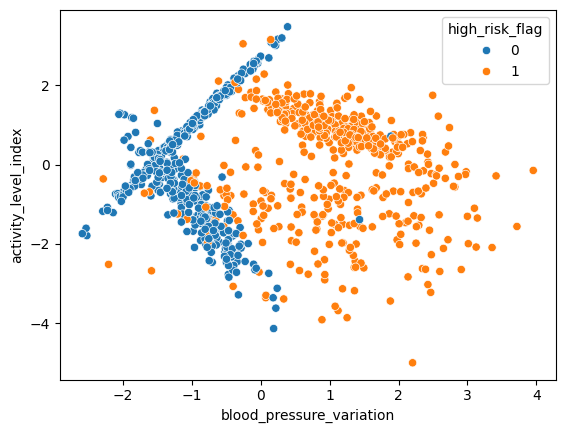

In [7]:
sns.scatterplot(x=df['blood_pressure_variation'],y=df['activity_level_index'],hue=df['high_risk_flag'])
plt.show()

In [8]:
df['high_risk_flag'].value_counts()

high_risk_flag
0    502
1    498
Name: count, dtype: int64

In [9]:
X=df.drop('high_risk_flag',axis=1)
y=df['high_risk_flag']

In [10]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=15)

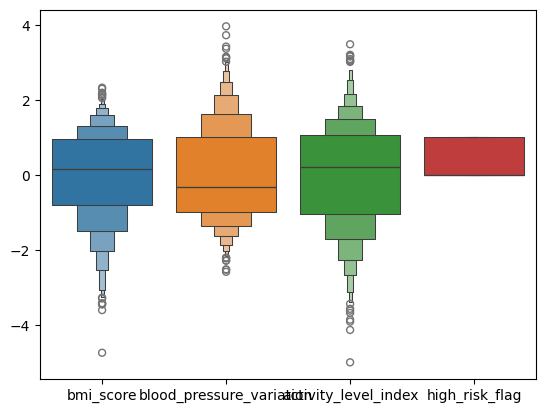

In [11]:
sns.boxenplot(df)
plt.show()

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
from sklearn.neighbors import KNeighborsClassifier

In [14]:
classifier=KNeighborsClassifier(n_neighbors=5,algorithm='auto')
classifier.fit(X_train_scaled,y_train)

KNeighborsClassifier()

In [15]:
y_pred=classifier.predict(X_test_scaled)

In [16]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report

In [17]:
print("confusion matrix: \n ", confusion_matrix(y_pred,y_test))
print("accuracy score: ", accuracy_score(y_pred,y_test))
print("classification report: ", classification_report(y_pred,y_test))

confusion matrix: 
  [[124  10]
 [  2 114]]
accuracy score:  0.952
classification report:                precision    recall  f1-score   support

           0       0.98      0.93      0.95       134
           1       0.92      0.98      0.95       116

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



In [24]:
# KNN algoritması, yeni bir veri geldiğinde ona en yakın komşuları bulmak için arkada bir arama yöntemi kullanır.
# kd_tree (K-Dimensional Tree), verileri ağaç yapısında organize ederek komşuları daha hızlı bulmayı sağlayan bir veri yapısıdır.
# Komşuları hangi yöntemle ararsanız arayın (ister tek tek her şeye bakarak, ister ağaç yapısıyla), günün sonunda bulacağınız en yakın komşular aynı kalır.
# Bu yüzden modelin tahmin başarısı (accuracy) değişmez. Ancak ağaç yapısı kullanmak, özellikle büyük veri setlerinde arama süresini kısaltır.
# Modelin genel başarısını (accuracy) doğrudan etkileyen şey bu K sayısı yani (n_neighbors ) parametresidir.

In [ ]:
classifier=KNeighborsClassifier(n_neighbors=5,algorithm='kd_tree')
classifier.fit(X_train_scaled,y_train)

KNeighborsClassifier(algorithm='kd_tree')

In [19]:
y_pred=classifier.predict(X_test_scaled)
print("confusion matrix: \n ", confusion_matrix(y_pred,y_test))
print("accuracy score: ", accuracy_score(y_pred,y_test))
print("classification report: ", classification_report(y_pred,y_test))

confusion matrix: 
  [[124  10]
 [  2 114]]
accuracy score:  0.952
classification report:                precision    recall  f1-score   support

           0       0.98      0.93      0.95       134
           1       0.92      0.98      0.95       116

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



In [25]:
classifier=KNeighborsClassifier(n_neighbors=3,algorithm='auto') 
classifier.fit(X_train_scaled,y_train)

KNeighborsClassifier(n_neighbors=3)

In [26]:
y_pred=classifier.predict(X_test_scaled)
print("confusion matrix: \n ", confusion_matrix(y_pred,y_test))
print("accuracy score: ", accuracy_score(y_pred,y_test))
print("classification report: ", classification_report(y_pred,y_test))

confusion matrix: 
  [[125   9]
 [  1 115]]
accuracy score:  0.96
classification report:                precision    recall  f1-score   support

           0       0.99      0.93      0.96       134
           1       0.93      0.99      0.96       116

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250



In [ ]:
# KNN, regresyon için de kullanılabilir.

In [27]:
df_reg = pd.read_csv("12-house_energy_regression.csv")

In [28]:
df_reg.head()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
0,-0.167118,0.146714,-14.996950
1,-0.020902,0.117327,-12.678089
2,0.150419,0.364961,17.775455
3,0.555604,0.089581,6.661465
4,0.058209,-1.142970,-14.195530


In [ ]:
# avg_indoor_temp_change -> Son 24 saatteki iç mekan sıcaklığındaki değişim (°C)
# outdoor_humidity_level -> Dış ortam bağıl nemi (%)
# daily_energy_consumption_kwh -> Bir hane halkının bir günlük enerji tüketimi (kWh cinsinden).

In [29]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   avg_indoor_temp_change        1000 non-null   float64
 1   outdoor_humidity_level        1000 non-null   float64
 2   daily_energy_consumption_kwh  1000 non-null   float64
dtypes: float64(3)
memory usage: 23.6 KB


In [30]:
df_reg.describe()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
count,1000.000000,1000.000000,1000.000000
mean,0.033186,0.056982,1.766025
std,0.961603,1.014959,41.299085
min,-3.241267,-2.940389,-132.797922
25%,-0.611581,-0.651418,-25.600072
50%,0.036043,0.047742,1.065474
75%,0.648317,0.714886,28.766573
max,3.078881,3.852731,138.577662


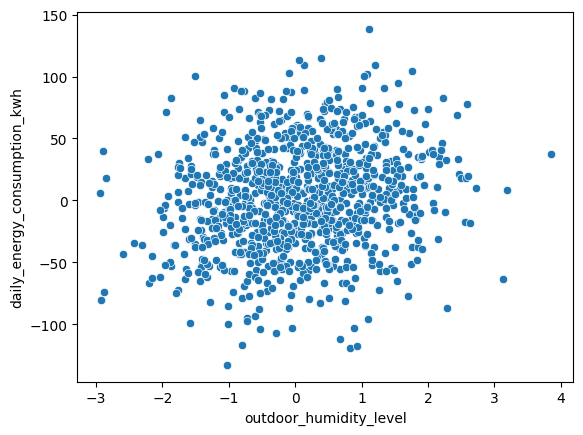

In [31]:
sns.scatterplot(x=df_reg['outdoor_humidity_level'],y=df_reg['daily_energy_consumption_kwh'])
plt.show()

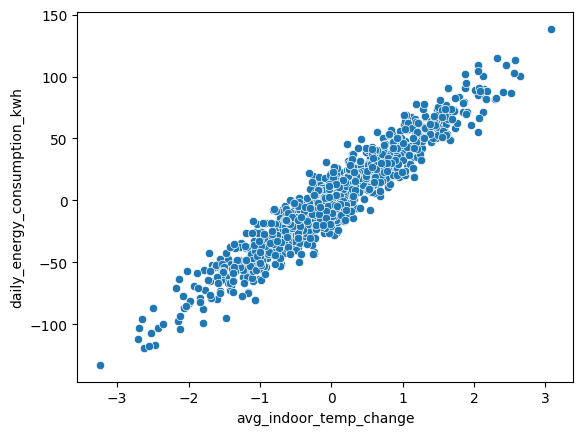

In [32]:
sns.scatterplot(x=df_reg['avg_indoor_temp_change'],y=df_reg['daily_energy_consumption_kwh'])
plt.show()

In [33]:
df_reg.corr()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
avg_indoor_temp_change,1.000000,0.002584,0.956682
outdoor_humidity_level,0.002584,1.000000,0.169557
daily_energy_consumption_kwh,0.956682,0.169557,1.000000


In [34]:
X=df_reg.drop('daily_energy_consumption_kwh',axis=1)
y=df_reg['daily_energy_consumption_kwh']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=15)

In [36]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [37]:
from sklearn.neighbors import KNeighborsRegressor

In [38]:
regressor=KNeighborsRegressor(n_neighbors=5,algorithm='auto')
regressor.fit(X_train_scaled,y_train)

KNeighborsRegressor()

In [39]:
y_pred=regressor.predict(X_test_scaled)

In [40]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [41]:
print("r2 score: ", r2_score(y_test,y_pred))
print("mean absolute error: ", mean_absolute_error(y_test,y_pred))
print("mean squared error: ", mean_squared_error(y_test,y_pred))

r2 score:  0.9152685146562609
mean absolute error:  9.42143518926242
mean squared error:  140.40201685069158


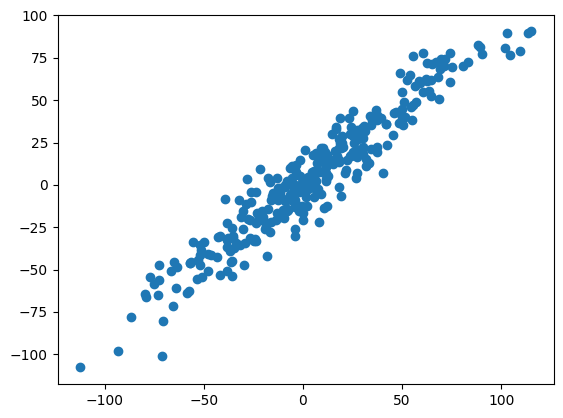

In [42]:
plt.scatter(y_test,y_pred)
plt.show()

In [43]:
# Farklı k değerleriyle tekrar test edebilirsiniz.

In [44]:
regressor=KNeighborsRegressor(n_neighbors=7,algorithm='auto')
regressor.fit(X_train_scaled,y_train)

KNeighborsRegressor(n_neighbors=7)

r2 score:  0.9164863388635838
mean absolute error:  9.331428506491209
mean squared error:  138.3840541750219


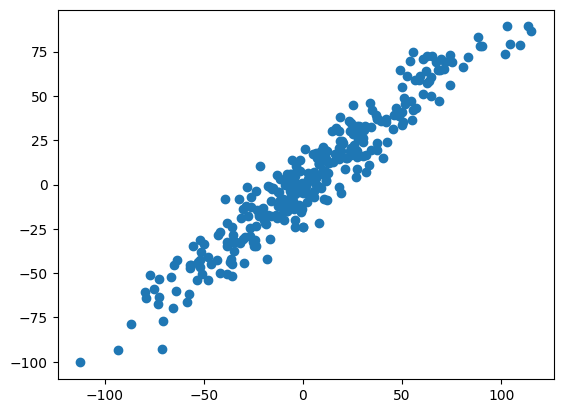

In [45]:
y_pred=regressor.predict(X_test_scaled)
print("r2 score: ", r2_score(y_test,y_pred))
print("mean absolute error: ", mean_absolute_error(y_test,y_pred))
print("mean squared error: ", mean_squared_error(y_test,y_pred))
plt.scatter(y_test,y_pred)
plt.show()

In [ ]:
regressor=KNeighborsRegressor(n_neighbors=25,algorithm='auto') # K değerlerini abartırsanız, ölçümleriniz azalacaktır.
regressor.fit(X_train_scaled,y_train)

KNeighborsRegressor(n_neighbors=25)

r2 score:  0.9118719343331324
mean absolute error:  9.42127621485675
mean squared error:  146.0302284396658


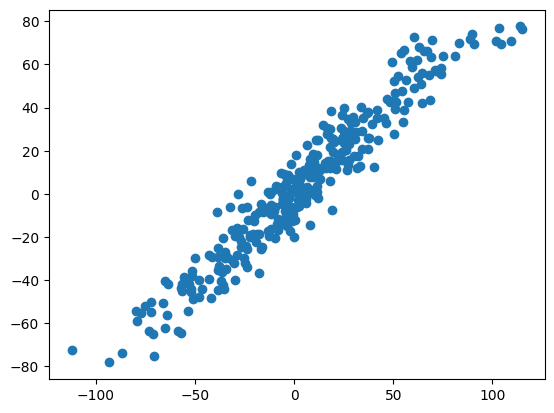

In [47]:
y_pred=regressor.predict(X_test_scaled)
print("r2 score: ", r2_score(y_test,y_pred))
print("mean absolute error: ", mean_absolute_error(y_test,y_pred))
print("mean squared error: ", mean_squared_error(y_test,y_pred))
plt.scatter(y_test,y_pred)
plt.show()